# Language Support OCR: Persian Handwriting to English

Displays `samples/persian-writing.jpeg`, extracts Persian handwriting with Mistral OCR-4, translates it with Azure Translator, and renders the English result as Markdown.

In [34]:
# Import required libraries
import base64
import os
import re
from pathlib import Path

import requests
from dotenv import load_dotenv
from IPython.display import Image, Markdown, display

# 2. Load environment variables and paths
load_dotenv()
ENDPOINT = os.getenv('AZURE_MISTRAL_DOCUMENT_AI_ENDPOINT')
API_KEY = os.getenv('AZURE_MISTRAL_DOCUMENT_AI_KEY')
MODEL_NAME = os.getenv('AZURE_AI_DEPLOYMENT_NAME')
IMAGE_PATH = Path.cwd() / 'samples' / 'persian-writing.jpeg'
HEADERS = {'Content-Type': 'application/json', 'Authorization': f'Bearer {API_KEY}'}


In [35]:
# Encode image and call OCR-4
def encode_image(image_path: Path) -> str:
    with open(image_path, 'rb') as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')


def call_ocr4(image_path: Path) -> dict:
    encoded_image = encode_image(image_path)
    document = {
        'type': 'document_url',
        'document_url': f'data:image/jpeg;base64,{encoded_image}',
    }
    payload = {
        'model': MODEL_NAME,
        'document': document,
        'include_blocks': True,
        'confidence_scores_granularity': 'page',
    }
    minimal_payload = {'model': MODEL_NAME, 'document': document}
    if not ENDPOINT or not API_KEY or not MODEL_NAME:
        raise RuntimeError(
            'Set AZURE_MISTRAL_DOCUMENT_AI_ENDPOINT, '
            'AZURE_MISTRAL_DOCUMENT_AI_KEY, and AZURE_AI_DEPLOYMENT_NAME.'
        )

    response = requests.post(ENDPOINT, json=payload, headers=HEADERS, timeout=120)
    if response.status_code == 422:
        response = requests.post(
            ENDPOINT,
            json=minimal_payload,
            headers=HEADERS,
            timeout=120,
        )
    response.raise_for_status()
    try:
        return response.json()
    except requests.exceptions.JSONDecodeError as error:
        raise RuntimeError(
            f'OCR endpoint returned non-JSON content: {response.text[:500]}'
        ) from error

    # Extract Persian text from the OCR-4 response

def extract_persian_text(ocr_response: dict) -> str:
    parts = []
    for page in ocr_response.get('pages', []):
        if page.get('markdown'):
            parts.append(page['markdown'])
        else:
            parts.extend(
                block.get('content', '')
                for block in page.get('blocks', [])
                if block.get('content')
            )

    persian_text = re.sub(r'\s+', ' ', '\n'.join(parts)).strip()
    if not persian_text:
        raise ValueError('OCR-4 returned no recognizable text.')
    return persian_text

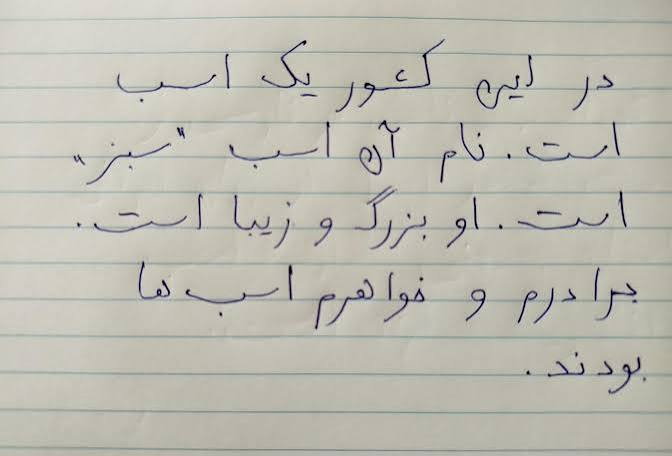

In [36]:
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f'Could not find {IMAGE_PATH}')
display(Image(filename=str(IMAGE_PATH)))

In [37]:

ocr_response = call_ocr4(IMAGE_PATH)
persian_text = extract_persian_text(ocr_response)
display('Persian OCR text:', persian_text)


# 8. Optional local fallback OCR (requires Tesseract and fas.traineddata)
# from PIL import Image as PILImage
# import pytesseract
# persian_text = pytesseract.image_to_string(PILImage.open(IMAGE_PATH), lang='fas')

'Persian OCR text:'

'در این کغور یک اسب است. نام آن اسب "سبز" است. او بزرگ و زیبا است. جرادرم و خواهرم اسب ها بودند.'

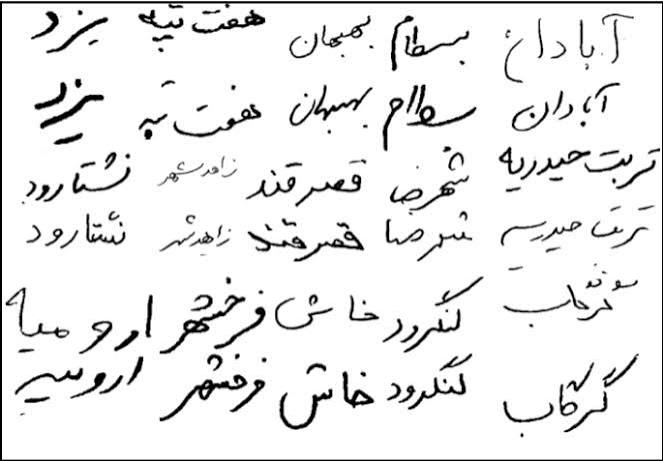

In [38]:
IMAGE_PATH = Path.cwd() / 'samples' / 'persian_script.jpeg'
display(Image(filename=str(IMAGE_PATH)))

In [39]:
ocr_response = call_ocr4(IMAGE_PATH)
persian_text = extract_persian_text(ocr_response)
display('Persian OCR text:', persian_text)

'Persian OCR text:'

'| آباد | بسط | بُجْمَان | هَفْتِ نِيَّة | بَزْد | | --- | --- | --- | --- | --- | | آباد | بسط | بُجْمَان | هَفْتِ نِيَّة | بَزْد | | تربیت حیدریه | شُحْصَا | قَصْرَقَنْد | نَاهِدْشَهْر | نَشْتَارُوْد | | تربیت حیدریه | شُحْصَا | قَصْرَقَنْد | نَاهِدْشَهْر | نَشْتَارُوْد | | سوفیاب | لَنْدَرُوْد خَاسْ | فَرْخَهْر | اِرْوَسْیَا | | | کُرْطَاب | لَنْدَرُوْد خَاسْ | فَرْخَهْر | اِرْوَسْیَا | |'